Smart Bridge : FatalAI: Fetal Health Classification

In [1]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('darkgrid')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

import warnings
warnings.filterwarnings(action='ignore')

Read the Dataset, verify Data and see it's shape

In [2]:
data = pd.read_csv("fetal_health.csv")

Check Data Types and non-null values 

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability             

In [4]:
data.isnull().sum()

baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histogram_mode                          

In [5]:
data['fetal_health'].value_counts()


fetal_health
1.0    1655
2.0     295
3.0     176
Name: count, dtype: int64

<Axes: xlabel='fetal_health', ylabel='count'>

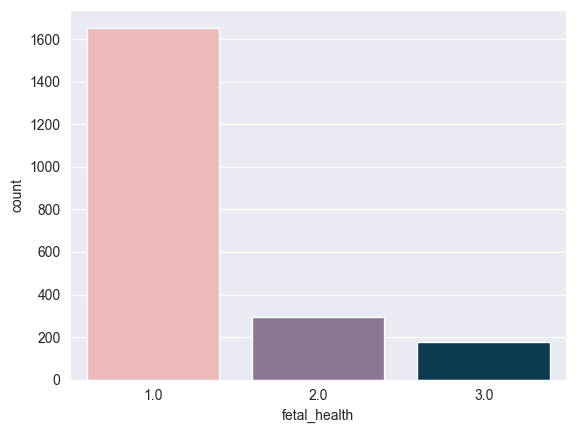

In [6]:
colours=["#f7b2b0","#8f7198", "#003f5c"]
sns.countplot(data=data, x="fetal_health", palette=colours)

Exploratory Data Analysis


In [7]:
data.describe().T


,count,mean,std,min,25%,50%,75%,max
baseline value,2126.0,133.303857,9.840844,106.0,126.000,133.000,140.000,160.000
accelerations,2126.0,0.003178,0.003866,0.0,0.000,0.002,0.006,0.019
fetal_movement,2126.0,0.009481,0.046666,0.0,0.000,0.000,0.003,0.481
uterine_contractions,2126.0,0.004366,0.002946,0.0,0.002,0.004,0.007,0.015
light_decelerations,2126.0,0.001889,0.002960,0.0,0.000,0.000,0.003,0.015
severe_decelerations,2126.0,0.000003,0.000057,0.0,0.000,0.000,0.000,0.001
prolongued_decelerations,2126.0,0.000159,0.000590,0.0,0.000,0.000,0.000,0.005
abnormal_short_term_variability,2126.0,46.990122,17.192814,12.0,32.000,49.000,61.000,87.000
mean_value_of_short_term_variability,2126.0,1.332785,0.883241,0.2,0.700,1.200,1.700,7.000
percentage_of_time_with_abnormal_long_term_variability,2126.0,9.846660,18.396880,0.0,0.000,0.000,11.000,91.000


*Visual Analysis*

1. Univariate Analysis


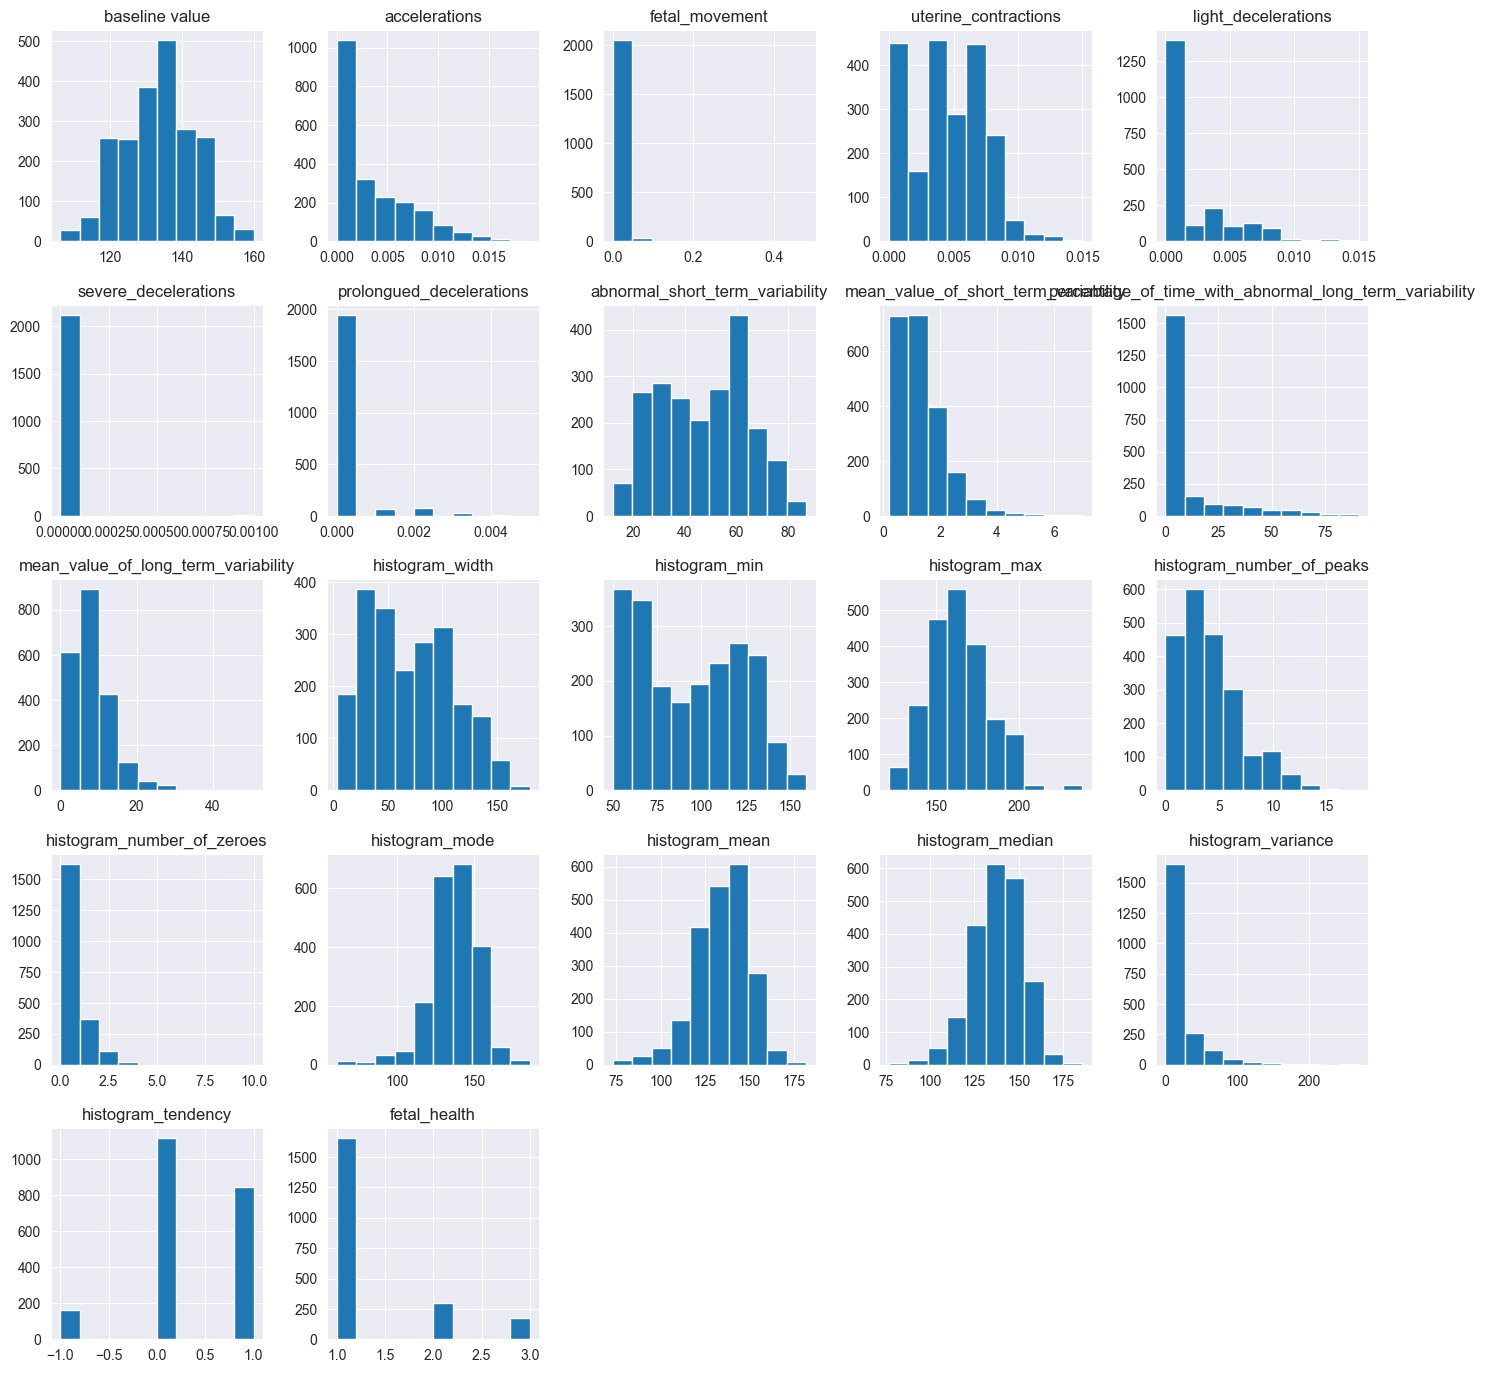

In [8]:
data.hist(figsize=(17,17), layout=(5,5), sharex=False)
plt.show()

Bivariate Analysis 


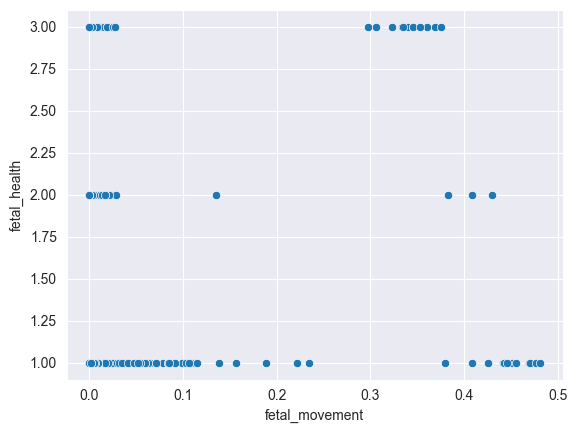

In [9]:
sns.scatterplot(x=data['fetal_movement'], y=data['fetal_health'])
plt.show()

Multivariate Analysis

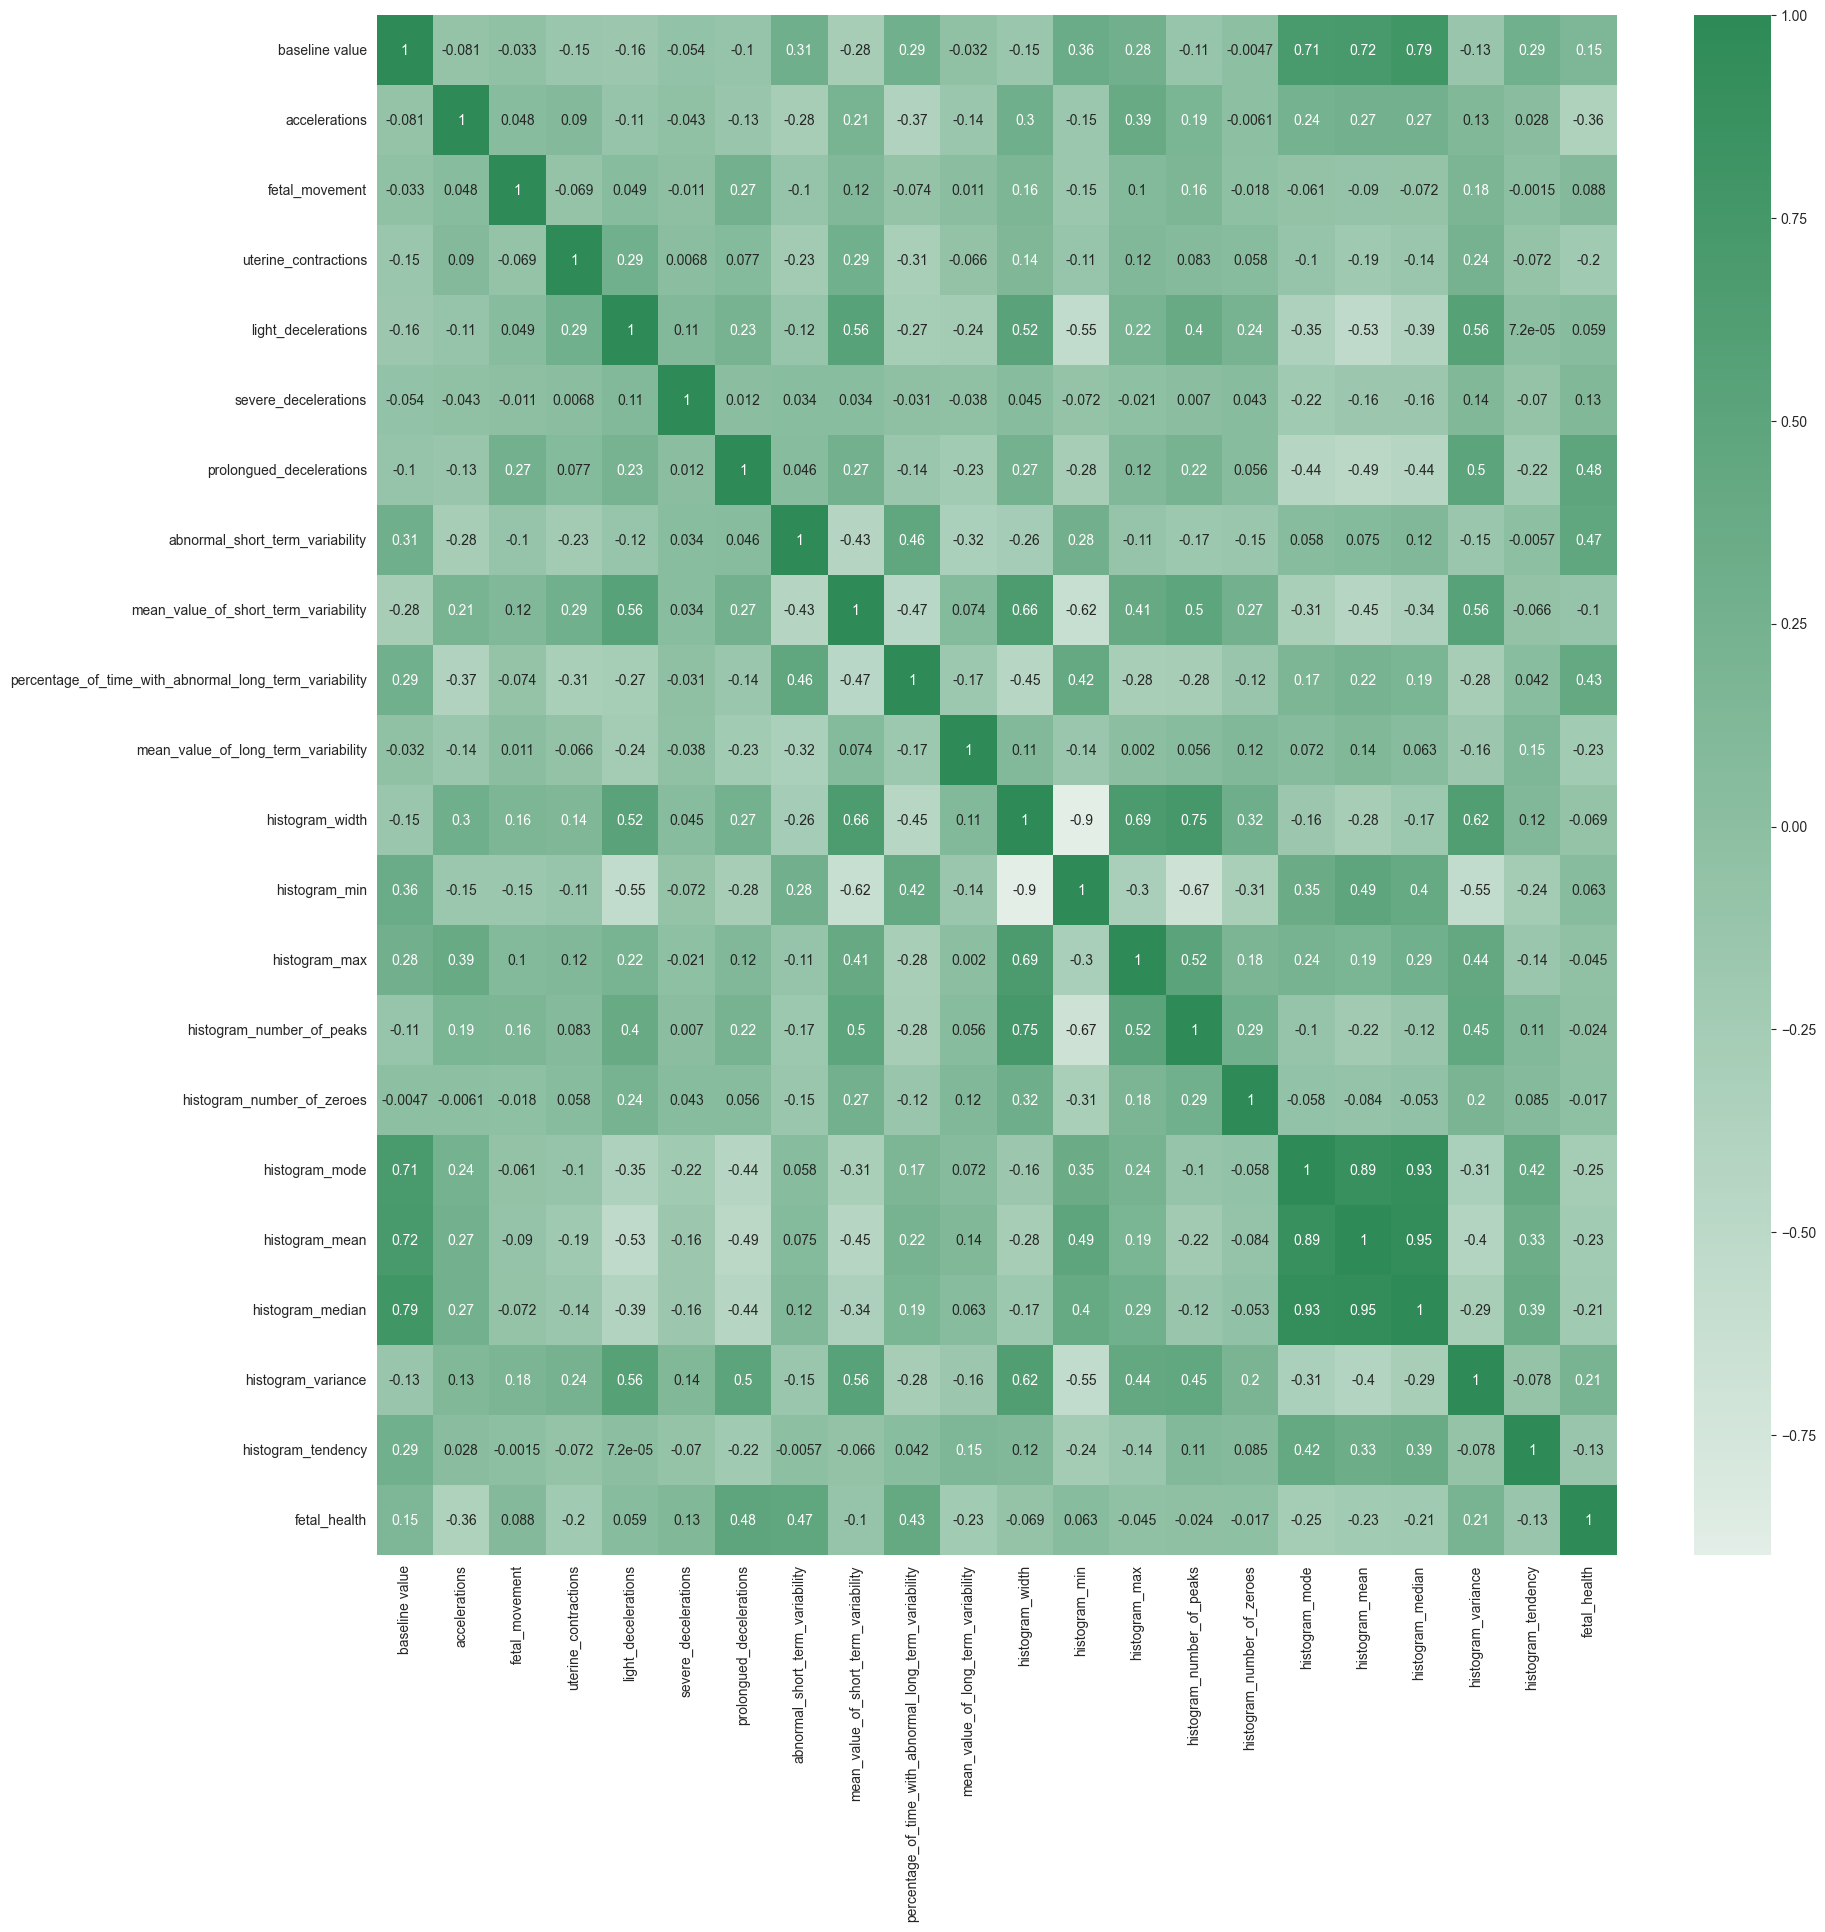

In [10]:
corrmat = data.corr()
plt.figure(figsize=(20,20))
cmap = sns.light_palette("seagreen", as_cmap=True)
sns.heatmap(corrmat, annot=True, cmap=cmap, center=0)
plt.show()

Feature Selection

In [11]:
data.drop(columns=["histogram_mean"], inplace=True)
data.corr()["fetal_health"].sort_values(ascending=False)

fetal_health                                              1.000000
prolongued_decelerations                                  0.484859
abnormal_short_term_variability                           0.471191
percentage_of_time_with_abnormal_long_term_variability    0.426146
histogram_variance                                        0.206630
baseline value                                            0.148151
severe_decelerations                                      0.131934
fetal_movement                                            0.088010
histogram_min                                             0.063175
light_decelerations                                       0.058870
histogram_number_of_zeroes                               -0.016682
histogram_number_of_peaks                                -0.023666
histogram_max                                            -0.045265
histogram_width                                          -0.068789
mean_value_of_short_term_variability                     -0.10

Define Variables and scale Data


In [12]:
X = data.drop(columns=['fetal_health'])
y = data["fetal_health"]

from sklearn.preprocessing import MinMaxScaler
scale = MinMaxScaler()
X_scaled = pd.DataFrame(scale.fit_transform(X), columns=X.columns)
X_scaled.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_median,histogram_variance,histogram_tendency
0,0.259259,0.000000,0.0,0.000000,0.0,0.0,0.0,0.813333,0.044118,0.472527,0.047337,0.344633,0.110092,0.034483,0.111111,0.0,0.472441,0.403670,0.271375,1.0
1,0.481481,0.315789,0.0,0.400000,0.2,0.0,0.0,0.066667,0.279412,0.000000,0.205128,0.717514,0.165138,0.655172,0.333333,0.1,0.637795,0.577982,0.044610,0.5
2,0.500000,0.157895,0.0,0.533333,0.2,0.0,0.0,0.053333,0.279412,0.000000,0.264300,0.717514,0.165138,0.655172,0.277778,0.1,0.637795,0.559633,0.048327,0.5
3,0.518519,0.157895,0.0,0.533333,0.2,0.0,0.0,0.053333,0.323529,0.000000,0.453649,0.644068,0.027523,0.413793,0.611111,0.0,0.606299,0.550459,0.048327,1.0
4,0.481481,0.368421,0.0,0.533333,0.0,0.0,0.0,0.053333,0.323529,0.000000,0.392505,0.644068,0.027523,0.413793,0.500000,0.0,0.606299,0.559633,0.040892,1.0


Train-Test Split

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)
print(X_train.shape, X_test.shape)

(1488, 20) (638, 20)


Apply SMOTE

In [14]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
X_train_smote, y_train_smote = smote.fit_resample(X_train.astype('float'), y_train)

from collections import Counter
print("Before SMOTE : ", Counter(y_train))
print("After SMOTE : ", Counter(y_train_smote))

Before SMOTE :  Counter({1.0: 1158, 2.0: 201, 3.0: 129})
After SMOTE :  Counter({1.0: 1158, 2.0: 1158, 3.0: 1158})


Training the model in multiple algorithms
Now our data is cleaned and it’s time to build the model. We can train our data on different algorithms. For this project we are applying three classification algorithms. The best model is saved based on its performance.

1.Random Forest

0.9545454545454546
For the amounts of training data is:  3474
Accuracy of RandomForestClassifier:  0.9545454545454546


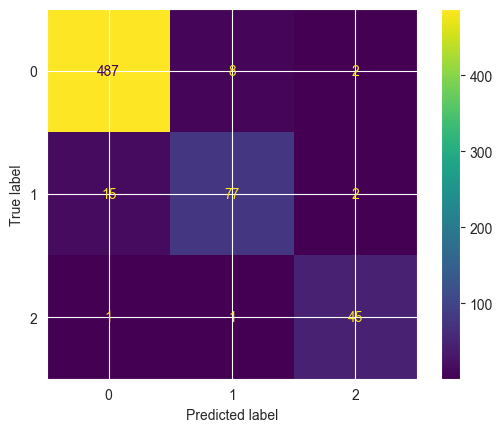

In [15]:
size = len(X_train_smote)

RF_model = RandomForestClassifier()
RF_model.fit(X_train_smote, y_train_smote)
predictions = RF_model.predict(X_test)
print(accuracy_score(y_test, predictions))

print("For the amounts of training data is: ", size)
print("Accuracy of RandomForestClassifier: ", RF_model.score(X_test, y_test))
cm = confusion_matrix(y_test, predictions)
cm_display = ConfusionMatrixDisplay(cm).plot()
plt.show()

Decision Tree

0.9388714733542319
For the amounts of training data is:  3474
Accuracy of DecisionTreeClassifier:  0.9388714733542319


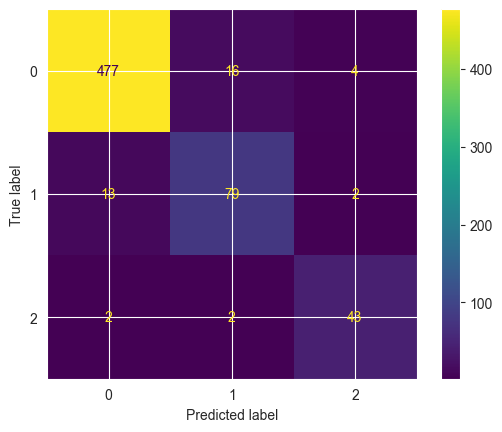

In [16]:
DT_model = DecisionTreeClassifier()
DT_model.fit(X_train_smote, y_train_smote)
predictions = DT_model.predict(X_test)
print(accuracy_score(y_test, predictions))

print("For the amounts of training data is: ", size)
print("Accuracy of DecisionTreeClassifier: ", DT_model.score(X_test, y_test))
cm = confusion_matrix(y_test, predictions)
cm_display = ConfusionMatrixDisplay(cm).plot()
plt.show()

Logistic Regression

0.7978056426332288
For the amounts of training data is:  3474
Accuracy of LogisticRegression:  0.7978056426332288


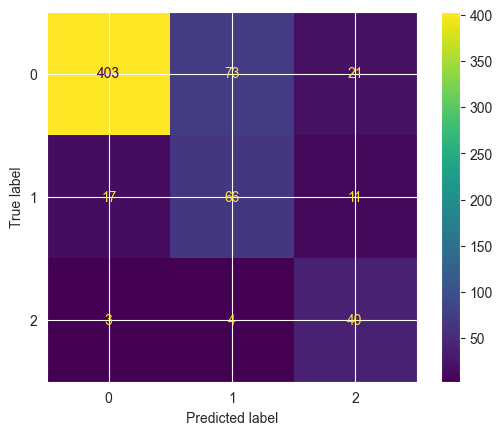

In [17]:
LR_model = LogisticRegression()
LR_model.fit(X_train_smote, y_train_smote)
predictions = LR_model.predict(X_test)
print(accuracy_score(y_test, predictions))

print("For the amounts of training data is: ", size)
print("Accuracy of LogisticRegression: ", LR_model.score(X_test, y_test))
cm = confusion_matrix(y_test, predictions)
cm_display = ConfusionMatrixDisplay(cm).plot()
plt.show()

K-Nearest Neighbors

0.8793103448275862
For the amounts of training data is:  3474
Accuracy of KNeighborsClassifier:  0.8793103448275862


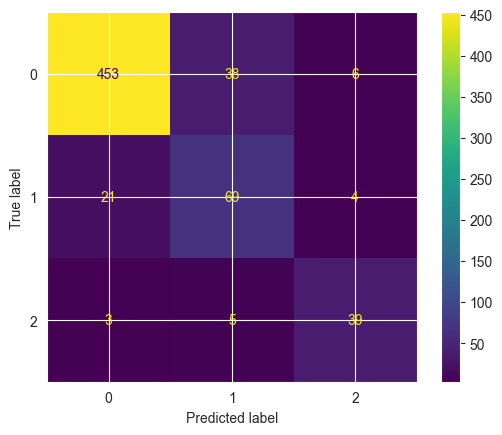

In [18]:
KNN_model = KNeighborsClassifier(n_neighbors=5)
KNN_model.fit(X_train_smote, y_train_smote)
predictions = KNN_model.predict(X_test)
print(accuracy_score(y_test, predictions))

print("For the amounts of training data is: ", size)
print("Accuracy of KNeighborsClassifier: ", KNN_model.score(X_test, y_test))
cm = confusion_matrix(y_test, predictions)
cm_display = ConfusionMatrixDisplay(cm).plot()
plt.show()

Testing the model

In [20]:
# 1. Redefine X with only the 8 selected features
selected_features = [
    "accelerations", 
    "prolongued_decelerations", 
    "abnormal_short_term_variability",
    "percentage_of_time_with_abnormal_long_term_variability", 
    "mean_value_of_long_term_variability",
    "histogram_variance", 
    "histogram_median", 
    "histogram_mode"
]

X = data[selected_features]
y = data["fetal_health"]

# 2. Re-split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)

# 3. Re-apply SMOTE
smote = SMOTE()
X_train_smote, y_train_smote = smote.fit_resample(X_train.astype('float'), y_train)

# 4. Re-train the Random Forest Model
RF_model = RandomForestClassifier()
RF_model.fit(X_train_smote, y_train_smote)

# 5. Run the test cases
print(RF_model.predict([[0.345, 0.1225, 23346, 0.23456, 0.987, 2345, 123, 0]]))
print(RF_model.predict([[0.000, 0.0, 73.0, 43.0, 2.4, 73.0, 120.0, 121.0]]))

[3.]
[2.]


Performance Testing and HyperParameter Tuning

In [25]:
# Re-train Decision Tree on the updated 8-feature data
DT_model = DecisionTreeClassifier()
DT_model.fit(X_train_smote, y_train_smote)

# Re-train Logistic Regression on the updated 8-feature data
LR_model = LogisticRegression()
LR_model.fit(X_train_smote, y_train_smote)

# Re-train K-Nearest Neighbors on the updated 8-feature data
KNN_model = KNeighborsClassifier(n_neighbors=5)
KNN_model.fit(X_train_smote, y_train_smote)

names = [
    'Random Forest Classifier', 
    'Logistic Regression', 
    'Decision Tree Classifier', 
    'K Neighbors Classifier'
]

scores = [
    RF_model.score(X_test, y_test),
    LR_model.score(X_test, y_test),
    DT_model.score(X_test, y_test),
    KNN_model.score(X_test, y_test)
]

df = pd.DataFrame()
df['name'] = names
df['score'] = scores
df

,name,score
0,Random Forest Classifier,0.948276
1,Logistic Regression,0.785266
2,Decision Tree Classifier,0.923197
3,K Neighbors Classifier,0.899687


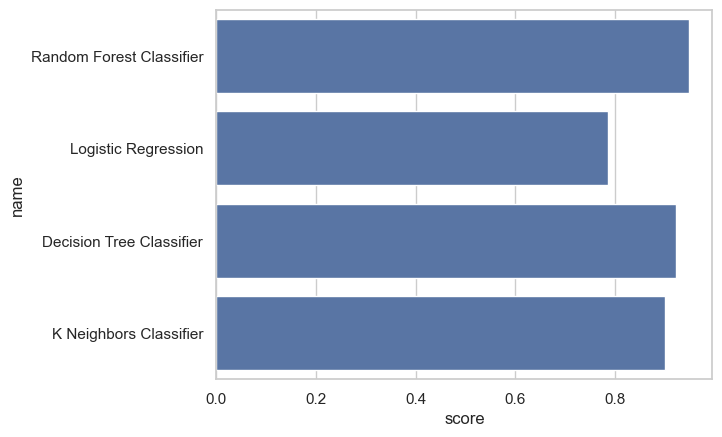

In [26]:
sns.set(style="whitegrid")
ax = sns.barplot(y="name", x="score", data=df)
plt.show()

Model Deployment

In [27]:
# saving the model
import pickle
pickle.dump(RF_model, open('fetal_health1.pkl', 'wb'))